# 04 - Order Forecasting｜新訂單預測

## 分析目的

本 Notebook 建立 **3 個月 New Orders Forecast**，並使用時間順序一致的 Rolling Backtest 比較多種方法。

分析流程依序為：

**環境確認**
→ **資料讀取與 Forecast Input Check**
→ **統一評估指標**
→ **6 組 Rolling 3-Month Backtest**
→ **Last Value Baseline**
→ **Seasonal Naive Baseline**
→ **Holt-Winters**
→ **Direct XGBoost**
→ **模型整體比較**
→ **Horizon 1 / 2 / 3 比較**
→ **Fold 穩定性**
→ **最佳模型選擇**
→ **未來 3 個月 Forecast**
→ **Planner Context**

## Forecast 設定

- **Target**：`new_orders`
- **Forecast Horizon**：3 months
- **Frequency**：Monthly
- **Main Metric**：WAPE
- **Supporting Metrics**：MAE、sMAPE
- **Backtest**：6 個不重疊的 3-month validation windows

## 分析原則

### 1. 不使用 Random Split

時間序列 Forecast 的 Validation 必須發生在 Training 之後，避免未來資料進入過去的模型訓練。

### 2. 複雜模型不預設一定較好

Baseline、Holt-Winters 與 XGBoost 使用相同 Backtest Windows 比較，最終模型由 out-of-sample WAPE 決定。

### 3. Forecast-Origin Features 不使用未來資訊

XGBoost Features 只使用 Forecast Origin 當月或更早已知的 Orders、Shipments、Backlog、Inventory、Industrial Production 與歷史 Lag / Rolling Features。

### 4. 最終 Forecast 是點預測，不是保證值

本 Notebook 尚未建立 Prediction Interval，因此最終 3 個月數值應視為 planning reference，而不是確定會發生的訂單金額。


## Step 0.1｜確認 Notebook 執行位置與 Python 環境

### 這一格要做什麼？

輸出三個環境資訊：

- Current Working Directory
- Python Interpreter
- 依目前程式推導的 Project Root

### 為什麼要檢查？

專案路徑與虛擬環境如果指向錯誤位置，後面即使程式本身沒有問題，也可能讀到錯誤資料或使用錯誤套件環境。

這一格也可確認先前曾出現的其他暫存路徑是否真的影響目前 Notebook 執行環境。


In [1]:
from pathlib import Path
import os
import sys

print("Current working directory:")
print(Path.cwd())

print("\nPython interpreter:")
print(sys.executable)

print("\nNotebook project root according to current code:")
print(Path.cwd().parent)

Current working directory:
C:\Users\momo8\Desktop\electronic-components-planning\notebooks

Python interpreter:
C:\Users\momo8\Desktop\electronic-components-planning\.venv\Scripts\python.exe

Notebook project root according to current code:
C:\Users\momo8\Desktop\electronic-components-planning


### 輸出解讀

實際輸出：

```text
Current working directory:
C:\Users\momo8\Desktop\electronic-components-planning\notebooks

Python interpreter:
C:\Users\momo8\Desktop\electronic-components-planning\.venv\Scripts\python.exe

Notebook project root according to current code:
C:\Users\momo8\Desktop\electronic-components-planning
```

**白話解讀：**

Notebook 目前確實從 `electronic-components-planning\notebooks` 執行，而且 Python Interpreter 使用專案自己的 `.venv`。

因此先前 Warning 曾顯示的 `Documents\STAT4066\.tmp\...` 並不是本次 04 實際的 Project Root；目前資料與套件環境都指向正確專案。

**下一步：**確認 Forecasting 所需套件已安裝在同一個 `.venv`。


## Step 0.2｜確認 `statsmodels` 與 `xgboost` 已安裝

### 這一格要做什麼？

使用目前 Notebook Kernel 對應的 Python 環境確認：

- `statsmodels`
- `xgboost`

是否已安裝。

`statsmodels` 用於 Holt-Winters；`xgboost` 用於 Direct XGBoost Forecast。


In [2]:
%pip install statsmodels xgboost

Note: you may need to restart the kernel to use updated packages.


### 輸出解讀

輸出顯示：

- `statsmodels 0.15.0`：已安裝
- `xgboost 3.2.0`：已安裝
- `numpy 2.4.6`
- `pandas 3.0.6`

而且安裝位置都在：

`electronic-components-planning\.venv\Lib\site-packages`

**白話解讀：**

Holt-Winters 與 XGBoost 套件目前已正確存在專案虛擬環境中，不需要再次下載。

畫面中的 `Requirement already satisfied` 不是錯誤，只代表套件原本已安裝。

**下一步：**確認 XGBRegressor 需要的 scikit-learn 相依套件。


## Step 0.3｜確認 `scikit-learn` 相依套件

### 這一格要做什麼？

確認：

- `statsmodels`
- `scikit-learn`

已存在於目前 `.venv`。

### 為什麼需要 `scikit-learn`？

雖然模型由 `xgboost` 提供，但 `XGBRegressor` 使用 scikit-learn 相容介面，因此缺少 `scikit-learn` 時會無法建立模型。


In [3]:
%pip install statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.


### 輸出解讀

輸出顯示：

- `statsmodels 0.15.0`：已安裝
- `scikit-learn 1.9.1`：已安裝

安裝位置同樣位於專案 `.venv`。

**白話解讀：**

先前 `XGBRegressor` 曾因缺少 `scikit-learn` 無法建立模型；目前這個相依問題已排除。

**作品整理注意：**

正式 GitHub 版本通常不需要把 `%pip install ...` 當成分析步驟保留在 Notebook 中，可以改由 `requirements.txt` 記錄套件版本。這兩格在目前學習版本保留沒有問題。

**下一步：**正式 Import Forecasting 套件。


## Step 1｜載入 Forecasting 套件

### 這一格要做什麼？

載入：

- `numpy / pandas`：數值與資料處理
- `matplotlib`：圖表
- `ExponentialSmoothing`：Holt-Winters
- `XGBRegressor`：XGBoost regression
- `display`：顯示表格

### 為什麼先做 Import Check？

正式分析前先確認所有 Forecasting 套件都能在目前 Kernel 中正常載入，可避免模型執行到中途才因相依套件缺失停止。


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "statsmodels is not installed. Run:\n"
        "python -m pip install statsmodels"
    ) from error

try:
    from xgboost import XGBRegressor
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "xgboost is not installed. Run:\n"
        "python -m pip install xgboost"
    ) from error

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("Forecasting libraries loaded successfully.")


Forecasting libraries loaded successfully.


### 輸出解讀

實際輸出：

```text
Forecasting libraries loaded successfully.
```

代表：

- Holt-Winters 可以 Import。
- XGBoost 可以 Import。
- Python 環境沒有再出現缺少 `statsmodels` 或 `scikit-learn` 的錯誤。

**白話解讀：** Forecasting 環境已準備完成，可以正式讀取 03 的資料。

**下一步：**讀取已完成 Backlog 分析的月度 Dataset。


## Step 2｜讀取 03 的月度 Demand / Backlog 資料

### 這一格要做什麼？

讀取：

`reports/tables/backlog_monthly_metrics.csv`

Forecast 使用前面 Notebook 已驗證與整理的月資料，欄位包含：

- New Orders
- Shipments
- Unfilled Orders
- Inventories
- Industrial Production
- 前面建立的 Planning Metrics

### 為什麼直接接續 03？

分析流程保持單一路徑：

`01 Data Validation → 02 Demand vs Shipment → 03 Backlog → 04 Forecast`

這可以避免不同 Notebook 各自建立一套不一致的資料版本。


In [5]:
PROJECT_ROOT = Path.cwd().parent

INPUT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "backlog_monthly_metrics.csv"
)

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"03 output not found: {INPUT_PATH}\n"
        "Please run 03_backlog_analysis.ipynb first."
    )

forecast_data = pd.read_csv(
    INPUT_PATH,
    parse_dates=["date"],
)

forecast_data = (
    forecast_data
    .sort_values("date")
    .reset_index(drop=True)
)

print("Loaded:", INPUT_PATH)
print("Shape:", forecast_data.shape)
print(
    "Date range:",
    forecast_data["date"].min().date(),
    "to",
    forecast_data["date"].max().date(),
)

display(
    forecast_data[
        [
            "date",
            "new_orders",
            "shipments",
            "unfilled_orders",
            "industrial_production",
        ]
    ].tail(12)
)


Loaded: C:\Users\momo8\Desktop\electronic-components-planning\reports\tables\backlog_monthly_metrics.csv
Shape: (415, 28)
Date range: 1992-02-01 to 2026-08-01


,date,new_orders,shipments,unfilled_orders,industrial_production
403,2025-09-01,5132,5174,18096,165.6670
404,2025-10-01,5264,5207,18153,169.1163
405,2025-11-01,5288,5253,18188,169.7424
406,2025-12-01,5293,5315,18166,170.5402
407,2026-01-01,5382,5310,18238,176.7104
408,2026-02-01,5348,5302,18284,176.1804
409,2026-03-01,5406,5282,18408,173.6932
410,2026-04-01,5405,5319,18494,176.6948
411,2026-05-01,5579,5438,18635,184.1891
412,2026-06-01,5668,5567,18736,187.5187


### 輸出解讀

實際結果：

```text
Shape: (415, 28)
Date range: 1992-02-01 to 2026-08-01
```

最新月份 2026-08：

- New Orders = **5,769 百萬美元**
- Shipments = **5,625 百萬美元**
- Unfilled Orders = **19,021 百萬美元**
- Industrial Production = **190.0987**

最近 12 個月的 New Orders 從 2025-09 的 **5,132** 上升到 2026-08 的 **5,769**。

**白話解讀：**

04 已成功讀取 03 的完整輸出，而且 Forecast Target 更新到 2026-08。資料期間與前面 Notebook 一致，沒有出現換檔後日期範圍不一致的情況。

**下一步：**執行 Forecast 專用的時間軸與資料完整性檢查。


## Step 3｜Forecast Input Check 與基本參數

### 這一格要做什麼？

設定：

- Forecast Horizon = **3 months**
- Backtest Folds = **6**
- XGBoost Training Window = **180 months**

並檢查：

- 必要欄位是否存在
- 日期是否重複
- New Orders 是否缺值
- 月份是否連續
- 歷史長度是否足夠

### 為什麼選 3 個月？

3 個月屬於短中期需求規劃範圍，能直接銜接後續 Backlog、Shipment、Capacity 與 Delivery Planning 情境。

### 為什麼 XGBoost 只使用最近 180 個月？

較早期的產業結構可能與目前差異很大。15 年窗口保留足夠 Training Samples，同時降低非常久以前資料對模型的影響。


In [6]:
FORECAST_HORIZON = 3
BACKTEST_FOLDS = 6
TRAINING_WINDOW_MONTHS = 180

required_columns = {
    "date",
    "new_orders",
    "shipments",
    "unfilled_orders",
    "inventories",
    "industrial_production",
}

missing_columns = required_columns - set(forecast_data.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

if forecast_data["date"].duplicated().any():
    raise ValueError("Duplicate dates were found.")

if forecast_data["new_orders"].isna().any():
    raise ValueError("New Orders contains missing values.")

expected_months = pd.date_range(
    start=forecast_data["date"].min(),
    end=forecast_data["date"].max(),
    freq="MS",
)

if not pd.DatetimeIndex(
    forecast_data["date"]
).equals(expected_months):
    raise ValueError(
        "Monthly dates are not continuous."
    )

minimum_required_rows = (
    24
    + BACKTEST_FOLDS * FORECAST_HORIZON
)

if len(forecast_data) < minimum_required_rows:
    raise ValueError(
        "Not enough history for the requested backtest."
    )

print("FORECAST INPUT CHECK: PASS")
print("Forecast horizon:", FORECAST_HORIZON, "months")
print("Backtest folds:", BACKTEST_FOLDS)
print(
    "XGBoost training window:",
    TRAINING_WINDOW_MONTHS,
    "months",
)


FORECAST INPUT CHECK: PASS
Forecast horizon: 3 months
Backtest folds: 6
XGBoost training window: 180 months


### 輸出解讀

實際輸出：

```text
FORECAST INPUT CHECK: PASS
Forecast horizon: 3 months
Backtest folds: 6
XGBoost training window: 180 months
```

代表：

- 日期沒有重複。
- New Orders 沒有缺值。
- 1992-02 到 2026-08 的月資料連續。
- 資料量足以建立 6 個 3-month Backtest Folds。

**白話解讀：**

Forecast 評估可以按照真正的時間順序執行，不需要補月或使用 Random Split。

XGBoost 每次最多使用 180 個月的近期 Training Origins。

**下一步：**建立所有模型共同使用的 Metrics。


## Step 4｜建立統一 Forecast 評估指標

### WAPE

`Σ|Actual − Forecast| / ΣActual × 100`

表示總絕對 Forecast Error 約占實際 New Orders 的百分比。

### MAE

每個月 Forecast 與 Actual 平均相差多少百萬美元。

### sMAPE

以 Actual 與 Forecast 的平均規模作為分母，補充相對百分比誤差。

### 為什麼所有模型使用同一個函數？

Baseline、Holt-Winters 與 XGBoost 若使用不同計算方式，就不能公平比較。因此所有模型都統一呼叫 `evaluate_forecast()`。


In [7]:
def evaluate_forecast(
    actual_values,
    predicted_values,
) -> dict[str, float]:

    actual = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted = np.asarray(
        predicted_values,
        dtype=float,
    )

    if actual.shape != predicted.shape:
        raise ValueError(
            "Actual and predicted arrays must have the same shape."
        )

    if actual.size == 0:
        raise ValueError(
            "Forecast evaluation requires observations."
        )

    if not np.isfinite(actual).all():
        raise ValueError(
            "Actual values contain NaN or infinity."
        )

    if not np.isfinite(predicted).all():
        raise ValueError(
            "Predicted values contain NaN or infinity."
        )

    absolute_error = np.abs(
        actual - predicted
    )

    mae = float(
        absolute_error.mean()
    )

    total_actual = float(
        actual.sum()
    )

    wape = (
        float(
            absolute_error.sum()
            / total_actual
            * 100
        )
        if total_actual != 0
        else np.nan
    )

    denominator = (
        np.abs(actual)
        + np.abs(predicted)
    )

    smape_components = np.where(
        denominator == 0,
        0.0,
        2
        * absolute_error
        / denominator,
    )

    smape = float(
        smape_components.mean()
        * 100
    )

    return {
        "mae": mae,
        "wape_pct": wape,
        "smape_pct": smape,
    }


test_metrics = evaluate_forecast(
    actual_values=[100, 120, 110],
    predicted_values=[105, 115, 108],
)

print(test_metrics)


{'mae': 4.0, 'wape_pct': 3.6363636363636362, 'smape_pct': 3.656076771581692}


### 輸出解讀

測試資料：

- Actual = `[100, 120, 110]`
- Forecast = `[105, 115, 108]`

實際輸出：

```text
MAE   = 4.0
WAPE  = 3.6364%
sMAPE = 3.6561%
```

**白話解讀：**

三個月份平均絕對誤差為 4 個單位，而總絕對誤差約占實際總量的 3.64%。

這格的目的只是確認 Metrics Function 計算正常，**不是本專案模型的 Forecast Performance**。

**下一步：**建立真正 out-of-sample 的 Rolling Backtest Windows。


## Step 5｜建立 6 個 Rolling 3-Month Backtest Windows

### 這一格要做什麼？

使用最新 18 個已知月份建立：

**6 Folds × 每 Fold 3 個月**

每一 Fold 都遵守：

`Forecast Origin → 後續 3 個月 Validation`

### 為什麼不用 Random Split？

Random Split 會破壞 Forecast 的時間順序。Rolling Backtest 模擬的是當時只能看到 Forecast Origin 以前資料的真實情境。


In [8]:
def build_backtest_windows(
    dataframe: pd.DataFrame,
    forecast_horizon: int,
    fold_count: int,
) -> pd.DataFrame:

    final_index = len(dataframe) - 1
    records = []

    for fold_number in range(1, fold_count + 1):

        periods_after_fold = (
            fold_count - fold_number
        )

        validation_end_index = (
            final_index
            - periods_after_fold
            * forecast_horizon
        )

        validation_start_index = (
            validation_end_index
            - forecast_horizon
            + 1
        )

        forecast_origin_index = (
            validation_start_index - 1
        )

        records.append(
            {
                "fold": fold_number,
                "origin_index": forecast_origin_index,
                "forecast_origin": (
                    dataframe.loc[
                        forecast_origin_index,
                        "date",
                    ]
                ),
                "validation_start": (
                    dataframe.loc[
                        validation_start_index,
                        "date",
                    ]
                ),
                "validation_end": (
                    dataframe.loc[
                        validation_end_index,
                        "date",
                    ]
                ),
            }
        )

    return pd.DataFrame(records)


backtest_windows = build_backtest_windows(
    dataframe=forecast_data,
    forecast_horizon=FORECAST_HORIZON,
    fold_count=BACKTEST_FOLDS,
)

display(backtest_windows)


,fold,origin_index,forecast_origin,validation_start,validation_end
0,1,396,2025-02-01,2025-03-01,2025-05-01
1,2,399,2025-05-01,2025-06-01,2025-08-01
2,3,402,2025-08-01,2025-09-01,2025-11-01
3,4,405,2025-11-01,2025-12-01,2026-02-01
4,5,408,2026-02-01,2026-03-01,2026-05-01
5,6,411,2026-05-01,2026-06-01,2026-08-01


### 輸出解讀

實際建立 6 個 Fold：

| Fold | Forecast Origin | Validation |
|---|---|---|
| 1 | 2025-02 | 2025-03 ～ 2025-05 |
| 2 | 2025-05 | 2025-06 ～ 2025-08 |
| 3 | 2025-08 | 2025-09 ～ 2025-11 |
| 4 | 2025-11 | 2025-12 ～ 2026-02 |
| 5 | 2026-02 | 2026-03 ～ 2026-05 |
| 6 | 2026-05 | 2026-06 ～ 2026-08 |

所有 Validation 都發生在 Forecast Origin 之後，Fold 6 也正好驗證到目前最新月份 2026-08。

**白話解讀：**

模型最後會在 **18 個真正未來月份**上接受評估，而不是拿 Training Data 自己評自己。

### 限制

這 6 個 Fold 只代表 **2025-03 至 2026-08 的近期 Forecast 表現**。雖然 Training History 很長，但模型比較結果不代表所有歷史景氣循環都會有相同排名。

**下一步：**建立最基本的 Forecast Baseline。


## Step 6｜建立兩個 Baseline Forecast

### Last Value

未來三個月都使用 Forecast Origin 當月的 New Orders。

### Seasonal Naive

每個 Forecast Month 使用去年同月 Actual。

### 為什麼一定要有 Baseline？

複雜模型只有在 out-of-sample 表現優於簡單方法時才有增加價值。若簡單 Baseline 已經較準，就不應因為模型較複雜而強行採用 XGBoost。


In [9]:
def last_value_forecast(
    history: pd.DataFrame,
    horizon: int,
) -> np.ndarray:

    last_value = float(
        history["new_orders"].iloc[-1]
    )

    return np.repeat(
        last_value,
        horizon,
    )


def seasonal_naive_forecast(
    full_data: pd.DataFrame,
    validation_dates: pd.Series,
) -> np.ndarray:

    lookup = (
        full_data
        .set_index("date")["new_orders"]
    )

    predictions = []

    for forecast_date in validation_dates:

        source_date = (
            pd.Timestamp(forecast_date)
            - pd.DateOffset(years=1)
        )

        if source_date not in lookup.index:
            raise ValueError(
                f"Missing seasonal source date: {source_date}"
            )

        predictions.append(
            float(lookup.loc[source_date])
        )

    return np.asarray(predictions)


print("Baseline functions created successfully.")


Baseline functions created successfully.


### 輸出解讀

實際輸出：

```text
Baseline functions created successfully.
```

代表：

- `last_value_forecast()` 已建立。
- `seasonal_naive_forecast()` 已建立。

目前尚未執行 Backtest，因此這一格**不能判斷哪個 Baseline 比較準**。

**白話解讀：** 兩個簡單方法已成為後續複雜模型必須超越的比較基準。

**下一步：**建立 Holt-Winters。


## Step 7｜建立 Holt-Winters Forecast

### 模型組成

- Additive Level
- Additive Trend
- Damped Trend
- 12-month Additive Seasonality

### 為什麼適合作為比較模型？

New Orders 是月資料，且有足夠長的歷史。Holt-Winters 可直接描述 Level、Trend 與 Seasonality，不需要額外大量 Features。


In [10]:
def holt_winters_forecast(
    history: pd.DataFrame,
    horizon: int,
) -> np.ndarray:

    series = (
        history
        .set_index("date")["new_orders"]
        .astype(float)
        .asfreq("MS")
    )

    model = ExponentialSmoothing(
        series,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated",
    )

    fitted_model = model.fit(
        optimized=True,
        use_brute=False,
    )

    predictions = fitted_model.forecast(
        horizon
    )

    return np.maximum(
        predictions.to_numpy(dtype=float),
        0.0,
    )


print("Holt-Winters function created successfully.")


Holt-Winters function created successfully.


### 輸出解讀

實際輸出：

```text
Holt-Winters function created successfully.
```

代表 Trend + 12-month Seasonality 的 Forecast Function 已建立。

**白話解讀：**

這一格只證明模型可以被建立，尚未產生 out-of-sample 分數，因此還不能說 Holt-Winters 是否有效。

**下一步：**建立 XGBoost 使用的 Forecast-Origin Features。


## Step 8｜建立 XGBoost Forecast-Origin Features

### Feature 設計

New Orders 歷史：

- Current
- Lag 1 / 2 / 3 / 6 / 12
- 3M / 6M / 12M Rolling Mean
- 3M / 12M Rolling Standard Deviation

Planning Context：

- Current Shipments
- 3M Average Shipments
- Current Backlog
- Current Inventories
- Current Industrial Production
- 3M Book-to-Bill

### Leakage 原則

所有 Features 都只使用 Forecast Origin 當月或更早的資訊。

### 為什麼使用 Direct Multi-Horizon？

Horizon 1、2、3 分開建立 Target，不使用前一個月的預測值遞迴產生下一個月，因此不會產生 recursive prediction error 的逐步累積。


In [11]:
def build_origin_features(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:

    result = dataframe[
        [
            "date",
            "new_orders",
            "shipments",
            "unfilled_orders",
            "inventories",
            "industrial_production",
        ]
    ].copy()

    orders = result["new_orders"]

    result["orders_current"] = orders

    for lag in [1, 2, 3, 6, 12]:
        result[f"orders_lag_{lag}"] = (
            orders.shift(lag)
        )

    for window in [3, 6, 12]:
        result[
            f"orders_roll_mean_{window}"
        ] = (
            orders
            .rolling(window=window)
            .mean()
        )

    result["orders_roll_std_3"] = (
        orders
        .rolling(window=3)
        .std()
    )

    result["orders_roll_std_12"] = (
        orders
        .rolling(window=12)
        .std()
    )

    result["shipments_current"] = (
        result["shipments"]
    )

    result["shipments_3m_avg"] = (
        result["shipments"]
        .rolling(window=3)
        .mean()
    )

    result["backlog_current"] = (
        result["unfilled_orders"]
    )

    result["inventories_current"] = (
        result["inventories"]
    )

    result["industrial_production_current"] = (
        result["industrial_production"]
    )

    result["book_to_bill_3m_origin"] = (
        result["new_orders"]
        .rolling(window=3)
        .mean()
        / result["shipments"]
        .rolling(window=3)
        .mean()
    )

    return result


origin_features = build_origin_features(
    forecast_data
)

feature_preview_columns = [
    "date",
    "orders_current",
    "orders_lag_1",
    "orders_lag_3",
    "orders_lag_12",
    "orders_roll_mean_3",
    "shipments_current",
    "backlog_current",
    "industrial_production_current",
    "book_to_bill_3m_origin",
]

display(
    origin_features[
        feature_preview_columns
    ].tail()
)


,date,orders_current,orders_lag_1,orders_lag_3,orders_lag_12,orders_roll_mean_3,shipments_current,backlog_current,industrial_production_current,book_to_bill_3m_origin
410,2026-04-01,5405,5406.0,5382.0,4978.0,5386.333333,5319,18494,176.6948,1.016098
411,2026-05-01,5579,5405.0,5348.0,5148.0,5463.333333,5438,18635,184.1891,1.021884
412,2026-06-01,5668,5579.0,5406.0,5192.0,5550.666667,5567,18736,187.5187,1.020093
413,2026-07-01,5711,5668.0,5405.0,5202.0,5652.666667,5570,18877,190.2607,1.023107
414,2026-08-01,5769,5711.0,5579.0,5158.0,5716.000000,5625,19021,190.0987,1.023028


### 輸出解讀

最新五個 Forecast Origins 的 Features 正常產生。

以 2026-08 為例：

- Current Orders = **5,769**
- Lag 1 = **5,711**
- Lag 3 = **5,579**
- Lag 12 = **5,158**
- 3M Orders Mean = **5,716**
- Current Shipments = **5,625**
- Current Backlog = **19,021**
- Industrial Production = **190.0987**
- 3M Book-to-Bill = **1.0230**

**白話解讀：**

所有 Lag 都指向過去資料，Rolling Features 也只使用 Forecast Origin 當下及以前的月份。

2026-08 的 Feature 狀態顯示近期 Orders 水準高於 1 年前，同時 3M Book-to-Bill 略高於 1。

### Leakage 判斷

這一格顯示的 Feature Construction 沒有直接使用 2026-09～2026-11 的未來 Actual，符合 Forecast-Origin 原則。

**下一步：**把這些 Features 分別對到 Horizon 1 / 2 / 3 Target。


## Step 9｜建立 Direct XGBoost Training Functions

### Training 方式

- Horizon 1：Origin Features → `t+1` New Orders
- Horizon 2：Origin Features → `t+2` New Orders
- Horizon 3：Origin Features → `t+3` New Orders

### 參數策略

本 Notebook 使用固定、偏保守的 XGBoost 設定，而不是利用 Outer Backtest 反覆調參。

### 為什麼這樣做？

Outer Backtest 的用途是評估泛化表現。如果根據同一組 Outer Validation 反覆修改參數，會讓最終分數過度樂觀。


In [12]:
BASE_FEATURE_COLUMNS = [
    "orders_current",
    "orders_lag_1",
    "orders_lag_2",
    "orders_lag_3",
    "orders_lag_6",
    "orders_lag_12",
    "orders_roll_mean_3",
    "orders_roll_mean_6",
    "orders_roll_mean_12",
    "orders_roll_std_3",
    "orders_roll_std_12",
    "shipments_current",
    "shipments_3m_avg",
    "backlog_current",
    "inventories_current",
    "industrial_production_current",
    "book_to_bill_3m_origin",
]


def add_target_month_features(
    feature_frame: pd.DataFrame,
    horizon: int,
) -> pd.DataFrame:

    result = feature_frame.copy()

    target_dates = (
        result["date"]
        + pd.DateOffset(months=horizon)
    )

    target_month = target_dates.dt.month

    result["target_month_sin"] = np.sin(
        2 * np.pi * target_month / 12
    )

    result["target_month_cos"] = np.cos(
        2 * np.pi * target_month / 12
    )

    return result


XGB_FEATURE_COLUMNS = (
    BASE_FEATURE_COLUMNS
    + [
        "target_month_sin",
        "target_month_cos",
    ]
)


def build_xgb_training_frame(
    full_data: pd.DataFrame,
    origin_feature_data: pd.DataFrame,
    horizon: int,
) -> pd.DataFrame:

    result = add_target_month_features(
        origin_feature_data,
        horizon=horizon,
    )

    result["target"] = (
        full_data["new_orders"]
        .shift(-horizon)
    )

    result = result.dropna(
        subset=XGB_FEATURE_COLUMNS + ["target"]
    ).copy()

    return result


def fit_xgb_model(
    training_frame: pd.DataFrame,
) -> XGBRegressor:

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=4,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.10,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        training_frame[XGB_FEATURE_COLUMNS],
        training_frame["target"],
        verbose=False,
    )

    return model


print("Direct XGBoost functions created successfully.")


Direct XGBoost functions created successfully.


### 輸出解讀

實際輸出：

```text
Direct XGBoost functions created successfully.
```

代表：

- XGBoost Feature Columns 已固定。
- Horizon 1 / 2 / 3 的 Target 會分別向未來移動。
- 模型使用固定參數，不會根據 Outer Backtest 分數反覆調整。

**白話解讀：**

XGBoost 已準備好進入公平比較，但目前仍沒有任何證據顯示它會比簡單模型更準。

**下一步：**執行四個模型的 6-Fold Backtest。


## Step 10｜執行 6-Fold Rolling Backtest

### 比較模型

1. `last_value`
2. `seasonal_naive`
3. `holt_winters`
4. `xgboost_direct`

每一個模型都在相同 Forecast Origin 與 Validation Dates 上產生 3 個月 Forecast。

### XGBoost 額外限制

每個 Fold 最多使用最近 **180 個 Training Origins**，避免非常久以前的資料支配目前模型。


In [13]:
def run_backtest(
    full_data: pd.DataFrame,
    windows: pd.DataFrame,
    origin_feature_data: pd.DataFrame,
) -> pd.DataFrame:

    prediction_records = []

    for window in windows.itertuples(index=False):

        origin_index = int(window.origin_index)

        history = full_data.iloc[
            : origin_index + 1
        ].copy()

        validation = full_data.iloc[
            origin_index + 1:
            origin_index + 1 + FORECAST_HORIZON
        ].copy()

        actual = validation[
            "new_orders"
        ].to_numpy(dtype=float)

        model_predictions = {}

        model_predictions["last_value"] = (
            last_value_forecast(
                history=history,
                horizon=FORECAST_HORIZON,
            )
        )

        model_predictions["seasonal_naive"] = (
            seasonal_naive_forecast(
                full_data=full_data.iloc[
                    : origin_index
                    + 1
                    + FORECAST_HORIZON
                ],
                validation_dates=validation["date"],
            )
        )

        model_predictions["holt_winters"] = (
            holt_winters_forecast(
                history=history,
                horizon=FORECAST_HORIZON,
            )
        )

        xgb_predictions = []

        for horizon in range(
            1,
            FORECAST_HORIZON + 1,
        ):

            training_frame = (
                build_xgb_training_frame(
                    full_data=full_data.iloc[
                        : origin_index + 1
                    ].reset_index(drop=True),
                    origin_feature_data=(
                        origin_feature_data.iloc[
                            : origin_index + 1
                        ].reset_index(drop=True)
                    ),
                    horizon=horizon,
                )
            )

            if len(training_frame) > TRAINING_WINDOW_MONTHS:
                training_frame = (
                    training_frame.tail(
                        TRAINING_WINDOW_MONTHS
                    )
                )

            model = fit_xgb_model(
                training_frame
            )

            origin_row = (
                origin_feature_data.iloc[
                    [origin_index]
                ].copy()
            )

            origin_row = (
                add_target_month_features(
                    origin_row,
                    horizon=horizon,
                )
            )

            prediction = float(
                model.predict(
                    origin_row[
                        XGB_FEATURE_COLUMNS
                    ]
                )[0]
            )

            xgb_predictions.append(
                max(prediction, 0.0)
            )

        model_predictions[
            "xgboost_direct"
        ] = np.asarray(
            xgb_predictions
        )

        for model_name, predictions in (
            model_predictions.items()
        ):

            for horizon_index in range(
                FORECAST_HORIZON
            ):

                prediction_records.append(
                    {
                        "fold": int(window.fold),
                        "forecast_origin": (
                            window.forecast_origin
                        ),
                        "model": model_name,
                        "horizon": (
                            horizon_index + 1
                        ),
                        "forecast_date": (
                            validation[
                                "date"
                            ].iloc[horizon_index]
                        ),
                        "actual": (
                            actual[
                                horizon_index
                            ]
                        ),
                        "prediction": (
                            float(
                                predictions[
                                    horizon_index
                                ]
                            )
                        ),
                    }
                )

    return pd.DataFrame(
        prediction_records
    )


backtest_predictions = run_backtest(
    full_data=forecast_data,
    windows=backtest_windows,
    origin_feature_data=origin_features,
)

print(
    "Backtest prediction rows:",
    len(backtest_predictions),
)

display(
    backtest_predictions.head(12)
)


Backtest prediction rows: 72


,fold,forecast_origin,model,horizon,forecast_date,actual,prediction
0,1,2025-02-01,last_value,1,2025-03-01,5147.0,4927.000000
1,1,2025-02-01,last_value,2,2025-04-01,4978.0,4927.000000
2,1,2025-02-01,last_value,3,2025-05-01,5148.0,4927.000000
3,1,2025-02-01,seasonal_naive,1,2025-03-01,5147.0,4777.000000
4,1,2025-02-01,seasonal_naive,2,2025-04-01,4978.0,4742.000000
5,1,2025-02-01,seasonal_naive,3,2025-05-01,5148.0,4827.000000
6,1,2025-02-01,holt_winters,1,2025-03-01,5147.0,4913.003135
7,1,2025-02-01,holt_winters,2,2025-04-01,4978.0,4897.225097
8,1,2025-02-01,holt_winters,3,2025-05-01,5148.0,4887.459320
9,1,2025-02-01,xgboost_direct,1,2025-03-01,5147.0,4872.100098


### 輸出解讀

實際輸出：

```text
Backtest prediction rows: 72
```

計算：

`6 folds × 4 models × 3 horizons = 72`

因此四個模型都成功完成所有 Backtest Predictions。

Fold 1 範例：

- Actual 2025-03 = **5,147**
- Last Value = **4,927**
- Seasonal Naive = **4,777**
- Holt-Winters = **4,913**
- XGBoost = **4,872.10**

**白話解讀：**

這裡開始出現真正的 out-of-sample Forecast 結果。Fold 1 已經顯示不同模型對同一個未來月份會產生不同預測，因此不能只看模型名稱判斷效果。

**下一步：**把 72 筆 Prediction 統一計算 WAPE、MAE 與 sMAPE。


## Step 11｜比較整體 Backtest Performance

### 這一格要做什麼？

把 6 Folds × 3 Horizons 的 out-of-sample predictions 合併，對四個模型計算：

- Pooled WAPE
- MAE
- sMAPE
- Mean Fold WAPE
- Fold WAPE Standard Deviation

### 模型選擇原則

以 **Pooled WAPE 最低**作為主要選擇條件，同時檢查不同 Fold 的穩定性。


In [14]:
model_summary_records = []
fold_metric_records = []

for model_name, model_group in (
    backtest_predictions.groupby("model")
):

    pooled_metrics = evaluate_forecast(
        actual_values=model_group["actual"],
        predicted_values=model_group["prediction"],
    )

    fold_wapes = []

    for fold_number, fold_group in (
        model_group.groupby("fold")
    ):

        fold_metrics = evaluate_forecast(
            actual_values=fold_group["actual"],
            predicted_values=fold_group["prediction"],
        )

        fold_wapes.append(
            fold_metrics["wape_pct"]
        )

        fold_metric_records.append(
            {
                "model": model_name,
                "fold": int(fold_number),
                **fold_metrics,
            }
        )

    model_summary_records.append(
        {
            "model": model_name,
            **pooled_metrics,
            "mean_fold_wape_pct": float(
                np.mean(fold_wapes)
            ),
            "std_fold_wape_pct": float(
                np.std(fold_wapes)
            ),
        }
    )


model_summary = (
    pd.DataFrame(model_summary_records)
    .sort_values("wape_pct")
    .reset_index(drop=True)
)

fold_metrics = pd.DataFrame(
    fold_metric_records
)

display(
    model_summary.round(3)
)

best_model_name = str(
    model_summary.iloc[0]["model"]
)

print()
print(
    "Best model by pooled WAPE:",
    best_model_name,
)


,model,mae,wape_pct,smape_pct,mean_fold_wape_pct,std_fold_wape_pct
0,last_value,98.778,1.851,1.862,1.848,0.852
1,holt_winters,106.288,1.991,2.008,1.988,1.013
2,xgboost_direct,222.218,4.164,4.229,4.141,1.060
3,seasonal_naive,398.722,7.471,7.728,7.437,1.078



Best model by pooled WAPE: last_value


### 輸出解讀

實際模型比較：

| Model | MAE | WAPE | sMAPE | Fold WAPE Std |
|---|---:|---:|---:|---:|
| **Last Value** | **98.78** | **1.851%** | **1.862%** | **0.852** |
| Holt-Winters | 106.29 | 1.991% | 2.008% | 1.013 |
| XGBoost Direct | 222.22 | 4.164% | 4.229% | 1.060 |
| Seasonal Naive | 398.72 | 7.471% | 7.728% | 1.078 |

最佳模型：

```text
last_value
```

### 白話解讀

近期 18 個 Validation Months 中，**最簡單的 Last Value Baseline 反而最準**。

Last Value 的 pooled WAPE = **1.851%**，略優於 Holt-Winters 的 **1.991%**，而且明顯優於 XGBoost 的 **4.164%** 與 Seasonal Naive 的 **7.471%**。

這個結果表示近期 New Orders 具有很強的短期 persistence：使用最新已知水準，對接下來三個月已經是一個很難被複雜模型穩定超越的基準。

### 不能下的結論

這不代表：

- XGBoost 本身是無效模型。
- Last Value 永遠會最好。
- 所有未來市場環境都維持相同排名。

目前只能說：**在這 6 個近期 Rolling Backtest Folds 中，Last Value 的 out-of-sample WAPE 最低。**

**下一步：**檢查不同 Forecast Horizon 是否有不同模型優勢。


## Step 12｜比較 Horizon 1 / 2 / 3 的誤差

### 這一格要做什麼？

分別計算：

- H1：1 個月 ahead
- H2：2 個月 ahead
- H3：3 個月 ahead

的 WAPE。

### 為什麼要分開？

Pooled WAPE 可能掩蓋「距離越遠越難 Forecast」的現象。Planner 在使用較遠月份的 Forecast 時，需要知道誤差是否隨 Horizon 增加。


In [15]:
horizon_metric_records = []

for (
    model_name,
    horizon,
), group in backtest_predictions.groupby(
    ["model", "horizon"]
):

    metrics = evaluate_forecast(
        actual_values=group["actual"],
        predicted_values=group["prediction"],
    )

    horizon_metric_records.append(
        {
            "model": model_name,
            "horizon": int(horizon),
            **metrics,
        }
    )


horizon_metrics = (
    pd.DataFrame(
        horizon_metric_records
    )
    .sort_values(
        ["model", "horizon"]
    )
)

horizon_wape_table = (
    horizon_metrics
    .pivot(
        index="model",
        columns="horizon",
        values="wape_pct",
    )
    .rename(
        columns={
            1: "H1_WAPE",
            2: "H2_WAPE",
            3: "H3_WAPE",
        }
    )
)

display(
    horizon_wape_table.round(3)
)


horizon,H1_WAPE,H2_WAPE,H3_WAPE
model,,,
holt_winters,1.520,1.843,2.603
last_value,1.388,1.547,2.608
seasonal_naive,6.828,7.845,7.733
xgboost_direct,3.229,3.931,5.315


### 輸出解讀

各 Horizon WAPE：

| Model | H1 | H2 | H3 |
|---|---:|---:|---:|
| Holt-Winters | 1.520% | 1.843% | **2.603%** |
| **Last Value** | **1.388%** | **1.547%** | 2.608% |
| Seasonal Naive | 6.828% | 7.845% | 7.733% |
| XGBoost Direct | 3.229% | 3.931% | 5.315% |

### 白話解讀

Last Value 在：

- H1 最低：**1.388%**
- H2 最低：**1.547%**

H3 則是 Holt-Winters **2.603%**，比 Last Value **2.608%** 只低約 **0.005 個百分點**，差異極小。

四個模型大致都呈現較遠 Horizon 更難預測的現象；XGBoost 從 H1 3.229% 上升到 H3 5.315%，增加最明顯。

### Planner 意義

1 個月與 2 個月 Forecast 的歷史誤差明顯低於 3 個月，因此較遠月份應保留更多不確定性。

**下一步：**檢查模型在不同時間 Fold 是否穩定。


## Step 13｜檢查不同 Backtest Period 的穩定性

### 這一格要做什麼？

列出並畫出每個模型在 6 個 Fold 的 WAPE。

### 主要觀察

- 哪個模型在多數 Fold 表現較好
- 是否存在單一期間突然失準
- 複雜模型是否真的比 Baseline 穩定
- 某個 Fold 是否對所有模型都較困難


model,holt_winters,last_value,seasonal_naive,xgboost_direct
fold,,,,
1,3.767,3.221,6.070,4.695
2,0.961,0.694,6.899,4.088
3,1.218,1.670,7.167,2.412
4,1.340,0.992,8.363,3.353
5,1.726,2.111,6.815,4.523
6,2.915,2.397,9.307,5.775


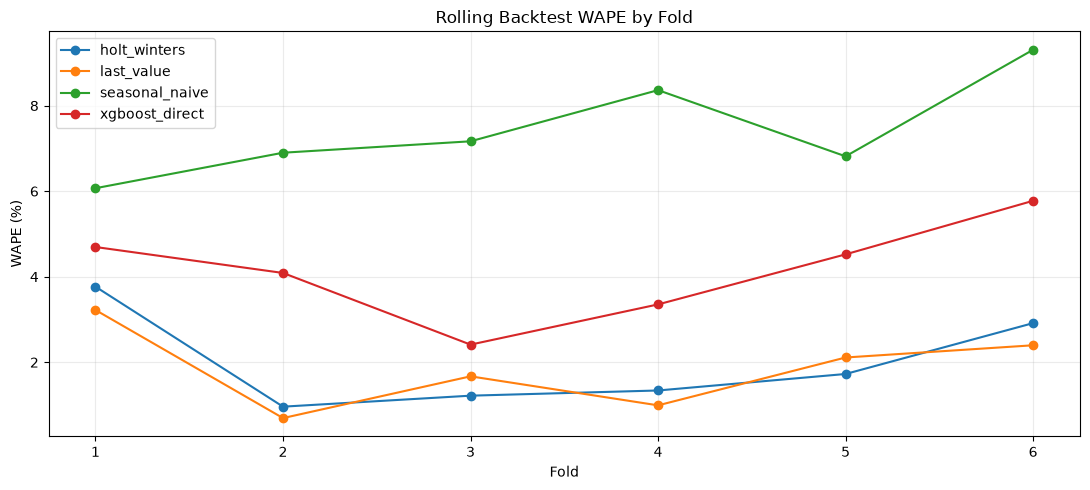

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\04_backtest_wape_by_fold.png


In [16]:
fold_wape_table = (
    fold_metrics
    .pivot(
        index="fold",
        columns="model",
        values="wape_pct",
    )
)

display(
    fold_wape_table.round(3)
)

fig, ax = plt.subplots(
    figsize=(11, 5)
)

for model_name in fold_wape_table.columns:
    ax.plot(
        fold_wape_table.index,
        fold_wape_table[model_name],
        marker="o",
        label=model_name,
    )

ax.set_title(
    "Rolling Backtest WAPE by Fold"
)
ax.set_xlabel("Fold")
ax.set_ylabel("WAPE (%)")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

REPORT_FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

REPORT_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    REPORT_FIGURE_DIR
    / "04_backtest_wape_by_fold.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

各 Fold WAPE：

| Fold | Holt-Winters | Last Value | Seasonal Naive | XGBoost |
|---|---:|---:|---:|---:|
| 1 | 3.767% | **3.221%** | 6.070% | 4.695% |
| 2 | 0.961% | **0.694%** | 6.899% | 4.088% |
| 3 | **1.218%** | 1.670% | 7.167% | 2.412% |
| 4 | 1.340% | **0.992%** | 8.363% | 3.353% |
| 5 | **1.726%** | 2.111% | 6.815% | 4.523% |
| 6 | 2.915% | **2.397%** | 9.307% | 5.775% |

### 白話解讀

- Last Value 在 **4 / 6 個 Fold** 最低。
- Holt-Winters 在 Fold 3、Fold 5 最低。
- XGBoost 沒有任何一個 Fold 成為最佳模型。
- Seasonal Naive 在所有 Fold 都明顯較差。

Last Value 並非每個期間都最佳，但在多數近期 Fold 勝出，而且 pooled WAPE 也最低。

Fold 6 中所有較複雜模型的誤差都有上升，其中 XGBoost = **5.775%**、Seasonal Naive = **9.307%**；Last Value 仍維持相對較低的 **2.397%**。

### 結論限制

Backtest 只有 6 Folds，因此 Fold 勝出次數應視為輔助證據，不應當作統計顯著性檢定。

**下一步：**依 pooled WAPE 選擇 Last Value，產生真正未來 3 個月 Forecast。


## Step 14｜產生最新 3 個月 Forecast

### 這一格要做什麼？

使用完整已知歷史資料，分別產生：

- 2026-09
- 2026-10
- 2026-11

的四種模型 Forecast。

`selected_forecast` 使用 Step 11 Backtest WAPE 最低的模型。

### 為什麼仍保留其他模型？

不同模型的 Forecast 差距可以作為一種 model disagreement 參考。但這不是正式 Prediction Interval，也不能直接轉成風險機率。


In [17]:
latest_date = forecast_data["date"].max()

future_dates = pd.date_range(
    start=(
        latest_date
        + pd.offsets.MonthBegin(1)
    ),
    periods=FORECAST_HORIZON,
    freq="MS",
)

final_forecasts = {}

final_forecasts["last_value"] = (
    last_value_forecast(
        history=forecast_data,
        horizon=FORECAST_HORIZON,
    )
)

final_forecasts["seasonal_naive"] = (
    seasonal_naive_forecast(
        full_data=forecast_data,
        validation_dates=pd.Series(
            future_dates
        ),
    )
)

final_forecasts["holt_winters"] = (
    holt_winters_forecast(
        history=forecast_data,
        horizon=FORECAST_HORIZON,
    )
)

xgb_final_predictions = []

for horizon in range(
    1,
    FORECAST_HORIZON + 1,
):

    training_frame = (
        build_xgb_training_frame(
            full_data=forecast_data,
            origin_feature_data=origin_features,
            horizon=horizon,
        )
    )

    if len(training_frame) > TRAINING_WINDOW_MONTHS:
        training_frame = (
            training_frame.tail(
                TRAINING_WINDOW_MONTHS
            )
        )

    model = fit_xgb_model(
        training_frame
    )

    latest_origin = (
        origin_features.tail(1).copy()
    )

    latest_origin = (
        add_target_month_features(
            latest_origin,
            horizon=horizon,
        )
    )

    prediction = float(
        model.predict(
            latest_origin[
                XGB_FEATURE_COLUMNS
            ]
        )[0]
    )

    xgb_final_predictions.append(
        max(prediction, 0.0)
    )

final_forecasts[
    "xgboost_direct"
] = np.asarray(
    xgb_final_predictions
)

final_forecast_table = pd.DataFrame(
    {
        "date": future_dates,
        **{
            model_name: predictions
            for model_name, predictions
            in final_forecasts.items()
        },
    }
)

final_forecast_table[
    "selected_forecast"
] = final_forecast_table[
    best_model_name
]

print(
    "Selected model:",
    best_model_name,
)

final_forecast_display = (
    final_forecast_table.copy()
)

numeric_columns = (
    final_forecast_display
    .select_dtypes(include="number")
    .columns
)

final_forecast_display[
    numeric_columns
] = (
    final_forecast_display[
        numeric_columns
    ]
    .round(2)
)

display(
    final_forecast_display
)


Selected model: last_value


,date,last_value,seasonal_naive,holt_winters,xgboost_direct,selected_forecast
0,2026-09-01,5769.0,5132.0,5771.39,5621.55,5769.0
1,2026-10-01,5769.0,5264.0,5796.20,5620.90,5769.0
2,2026-11-01,5769.0,5288.0,5803.92,5616.26,5769.0


### 輸出解讀

Backtest 自動選出的模型：

```text
Selected model: last_value
```

未來三個月：

| Date | Last Value | Seasonal Naive | Holt-Winters | XGBoost | Selected |
|---|---:|---:|---:|---:|---:|
| 2026-09 | **5,769** | 5,132 | 5,771.39 | 5,621.55 | **5,769** |
| 2026-10 | **5,769** | 5,264 | 5,796.20 | 5,620.90 | **5,769** |
| 2026-11 | **5,769** | 5,288 | 5,803.92 | 5,616.26 | **5,769** |

### 白話解讀

Selected Forecast 三個月全部都是 **5,769 百萬美元**，原因不是模型「預測未來一定完全不變」，而是 **Last Value Baseline 的定義本來就是把最新 Actual 水準延伸到每個 Forecast Horizon**。

其他模型對方向並不完全一致：

- Holt-Winters：小幅上升到約 5,804。
- XGBoost：略低於最新 Actual，約 5,616～5,622。
- Seasonal Naive：明顯較低，約 5,132～5,288。

這個 model disagreement 表示不同方法對趨勢與 seasonality 的假設不同。

### 重要限制

目前沒有正式 Prediction Interval，所以不能把模型間最大最小差距直接當成 95% Confidence Interval 或風險範圍。

**下一步：**把 Selected Forecast 與最近 24 個月 Actual 放在同一張圖。


## Step 15｜繪製 Recent Actual + Selected Forecast

### 這一格要做什麼？

圖中顯示：

- 最近 24 個月 Actual New Orders
- 未來 3 個月 Selected Forecast
- Actual 與 Forecast 的分界

### 為什麼只顯示最近 24 個月？

3 個月 Forecast 放在 30 多年完整歷史圖中會難以辨識。最近兩年更適合觀察當前 Demand Level 與短期 Forecast。


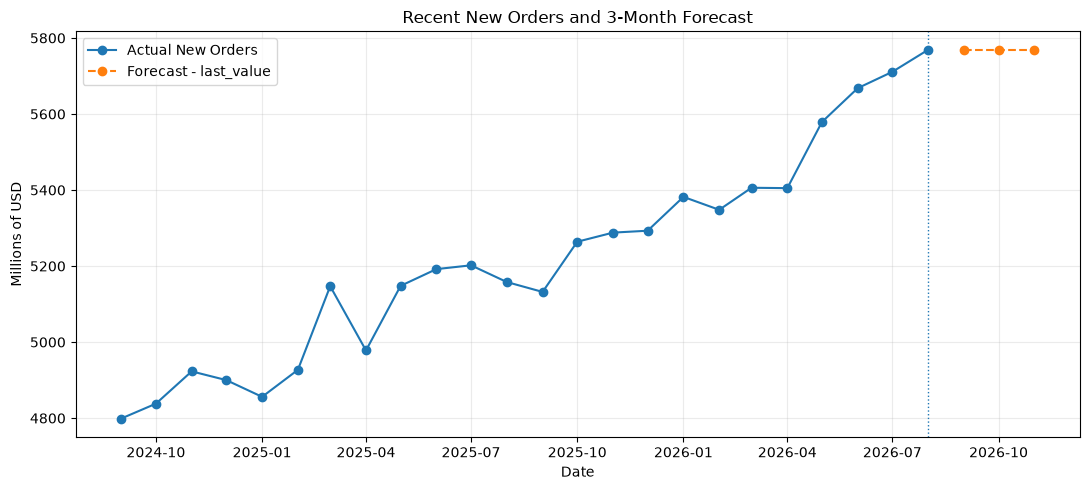

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\04_final_3_month_order_forecast.png


In [18]:
recent_actual = (
    forecast_data.tail(24)[
        ["date", "new_orders"]
    ]
)

fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    recent_actual["date"],
    recent_actual["new_orders"],
    marker="o",
    label="Actual New Orders",
)

ax.plot(
    final_forecast_table["date"],
    final_forecast_table[
        "selected_forecast"
    ],
    marker="o",
    linestyle="--",
    label=(
        f"Forecast - {best_model_name}"
    ),
)

ax.axvline(
    latest_date,
    linestyle=":",
    linewidth=1,
)

ax.set_title(
    "Recent New Orders and 3-Month Forecast"
)
ax.set_xlabel("Date")
ax.set_ylabel("Millions of USD")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "04_final_3_month_order_forecast.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

圖中最近 24 個月 Actual New Orders 整體由約 **4,800 百萬美元**逐步升到 2026-08 的 **5,769 百萬美元**，中間存在短期起伏。

Selected Forecast 從 2026-09 到 2026-11維持：

**5,769 百萬美元 / month**

### 白話解讀

圖表顯示的是：

> 近期 Actual Orders 已處在這兩年的相對高位，而最佳 Backtest 方法選擇「維持目前水準」作為未來三個月的點預測。

這不是「需求成長停止」的證據，只代表在近期 Backtest 中，假設短期維持最新水準的誤差最小。

圖中的 Forecast 平線來自 Last Value 方法本身，不能解讀成模型發現真正需求一定會是一條水平線。

**下一步：**加入 Backlog Coverage 與 Shipment Context，避免只從 Forecast 單獨判斷 Planning Pressure。


## Step 16｜把 Forecast 放回 Planner Context

### 這一格要做什麼？

整合：

- Latest New Orders
- Latest Shipments
- Latest Backlog
- Backlog Coverage
- 3M Book-to-Bill
- Selected Forecast Model
- Backtest WAPE
- 3M Forecast Average
- Forecast vs Latest Actual

### 為什麼不能只看 Forecast？

相同的 Order Forecast，在不同 Backlog Coverage 與 Shipment run-rate 下，Planning 意義不同。因此 Forecast 需要和目前履約狀態一起解讀。


In [19]:
latest_row = forecast_data.iloc[-1]

selected_model_row = (
    model_summary.loc[
        model_summary["model"].eq(
            best_model_name
        )
    ]
    .iloc[0]
)

forecast_average = float(
    final_forecast_table[
        "selected_forecast"
    ].mean()
)

forecast_change_vs_latest = (
    (
        forecast_average
        / float(
            latest_row["new_orders"]
        )
        - 1
    )
    * 100
)

planner_forecast_summary = pd.DataFrame(
    {
        "metric": [
            "Latest actual month",
            "Latest New Orders (USD mn)",
            "Latest Shipments (USD mn)",
            "Latest Backlog (USD mn)",
            "Latest Backlog Coverage (months)",
            "Latest 3M Book-to-Bill",
            "Selected Forecast Model",
            "Backtest WAPE",
            "3M Forecast Average (USD mn)",
            "Forecast Avg vs Latest Actual",
        ],
        "value": [
            latest_row[
                "date"
            ].strftime("%Y-%m"),
            round(
                float(
                    latest_row[
                        "new_orders"
                    ]
                ),
                2,
            ),
            round(
                float(
                    latest_row[
                        "shipments"
                    ]
                ),
                2,
            ),
            round(
                float(
                    latest_row[
                        "unfilled_orders"
                    ]
                ),
                2,
            ),
            round(
                float(
                    latest_row[
                        "backlog_coverage_months"
                    ]
                ),
                2,
            ),
            round(
                float(
                    latest_row[
                        "book_to_bill_3m"
                    ]
                ),
                3,
            ),
            best_model_name,
            (
                f"{selected_model_row['wape_pct']:.2f}%"
            ),
            round(
                forecast_average,
                2,
            ),
            (
                f"{forecast_change_vs_latest:.2f}%"
            ),
        ],
    }
)

display(
    planner_forecast_summary
)

print()
print("FORECAST DIRECTION")
print("-" * 60)

if forecast_change_vs_latest > 2:
    print(
        "The selected 3-month forecast is above the latest actual order level."
    )
elif forecast_change_vs_latest < -2:
    print(
        "The selected 3-month forecast is below the latest actual order level."
    )
else:
    print(
        "The selected 3-month forecast is broadly close to the latest actual order level."
    )


,metric,value
0,Latest actual month,2026-08
1,Latest New Orders (USD mn),5769.0
2,Latest Shipments (USD mn),5625.0
3,Latest Backlog (USD mn),19021.0
4,Latest Backlog Coverage (months),3.4
5,Latest 3M Book-to-Bill,1.023
6,Selected Forecast Model,last_value
7,Backtest WAPE,1.85%
8,3M Forecast Average (USD mn),5769.0
9,Forecast Avg vs Latest Actual,0.00%



FORECAST DIRECTION
------------------------------------------------------------
The selected 3-month forecast is broadly close to the latest actual order level.


### 輸出解讀

最終 Planner Forecast Summary：

| 指標 | 結果 |
|---|---:|
| Latest Actual Month | **2026-08** |
| Latest New Orders | **5,769 百萬美元** |
| Latest Shipments | **5,625 百萬美元** |
| Latest Backlog | **19,021 百萬美元** |
| Backlog Coverage | **3.40 months** |
| 3M Book-to-Bill | **1.023** |
| Selected Model | **last_value** |
| Backtest WAPE | **1.85%** |
| 3M Forecast Average | **5,769 百萬美元** |
| Forecast Avg vs Latest Actual | **0.00%** |

程式判讀：

```text
The selected 3-month forecast is broadly close to the latest actual order level.
```

### 白話解讀

最佳模型預測未來三個月 New Orders 平均維持最新的 **5,769 百萬美元**。

同時：

- 3M Book-to-Bill = **1.023**，近期 Orders 仍略高於 Shipments。
- Backlog = **19,021 百萬美元**。
- 03 已確認 Backlog Coverage = **3.40 months**，且最近 3 個月 Coverage 並未惡化。

因此目前較合理的 Planner 描述是：

> **短期 New Orders 預測維持目前高水準；Orders 仍略高於 Shipments，但現有 Backlog Coverage 並未同步惡化。**

### 限制

Backtest WAPE 1.85% 是最近 18 個 Validation Months 的歷史結果，不是未來三個月保證誤差一定只有 1.85%。

此外，本 Notebook 尚未建立 Prediction Interval，因此不能用點預測直接承諾精確訂單量或交期。

**下一步：**保存 Backtest 與 Final Forecast，供 05 進一步分析 Error / Bias。


## Step 17｜保存 04 Forecast 結果

### 這一格要做什麼？

保存六份正式輸出：

- Backtest Predictions
- Model Summary
- Fold Metrics
- Horizon Metrics
- Final 3-Month Forecast
- Planner Forecast Summary

這些檔案可供 05 Error Analysis、Dashboard 與最終簡報直接使用。


In [20]:
REPORT_TABLE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

REPORT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

output_files = {
    "order_forecast_backtest_predictions.csv": (
        backtest_predictions
    ),
    "order_forecast_model_summary.csv": (
        model_summary
    ),
    "order_forecast_fold_metrics.csv": (
        fold_metrics
    ),
    "order_forecast_horizon_metrics.csv": (
        horizon_metrics
    ),
    "final_3_month_order_forecast.csv": (
        final_forecast_table
    ),
    "order_forecast_planner_summary.csv": (
        planner_forecast_summary
    ),
}

for file_name, dataframe in (
    output_files.items()
):

    output_path = (
        REPORT_TABLE_DIR
        / file_name
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print("Saved:", file_name)


Saved: order_forecast_backtest_predictions.csv
Saved: order_forecast_model_summary.csv
Saved: order_forecast_fold_metrics.csv
Saved: order_forecast_horizon_metrics.csv
Saved: final_3_month_order_forecast.csv
Saved: order_forecast_planner_summary.csv


### 輸出解讀

六份檔案全部成功保存：

```text
order_forecast_backtest_predictions.csv
order_forecast_model_summary.csv
order_forecast_fold_metrics.csv
order_forecast_horizon_metrics.csv
final_3_month_order_forecast.csv
order_forecast_planner_summary.csv
```

## 04 最終結果

### 模型選擇

- **Best Model：Last Value**
- Pooled WAPE：**1.851%**
- MAE：**98.78 百萬美元**
- sMAPE：**1.862%**

### 其他模型

- Holt-Winters WAPE：**1.991%**
- XGBoost WAPE：**4.164%**
- Seasonal Naive WAPE：**7.471%**

### Forecast Horizon

- H1 Last Value WAPE：**1.388%**
- H2 Last Value WAPE：**1.547%**
- H3 Last Value WAPE：**2.608%**

預測距離增加後，誤差明顯變大。

### Final Forecast

2026-09 ～ 2026-11 Selected Forecast 均為：

**5,769 百萬美元 / month**

這是 Last Value 方法的結果，不代表未來需求確定完全不變。

## 客觀結論

近期資料顯示，簡單 Last Value Baseline 比 Holt-Winters、XGBoost 與 Seasonal Naive 更適合目前的 3-month New Orders Forecast。

這個結果本身具有 Planner 意義：

> **複雜模型沒有自動帶來更高預測準確度，模型選擇應依 out-of-sample backtest，而不是依模型複雜度。**

## 分析限制

- Backtest 僅涵蓋最近 18 個 Validation Months。
- 尚未建立 Forecast Bias Analysis。
- 尚未建立 Prediction Interval。
- 公開資料是美國電子元件製造業產業層級資料，不是單一公司或客戶訂單。

## 下一步

`05_forecast_evaluation.ipynb`

將進一步分析：

- Forecast Bias
- Over-Forecast / Under-Forecast
- Worst Fold
- Worst Horizon
- Forecast uncertainty
- Planner 使用 Forecast 時需要保留的安全邊界
